In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns
from prophet import Prophet

# 1. DATA ACQUISITION & MULTI-INDEX FIX
# Using auto_adjust=True to handle the 'Adj Close' -> 'Close' API shift of 2025/26
tickers = ["UNH", "MSFT", "JPM", "LLY", "COST", "V", "WM", "NEE", "MSCI", "PG"]
raw_data = yf.download(tickers, start="2021-01-01", end="2026-04-27", auto_adjust=True)

# Select 'Close' which now represents Adjusted Close in yfinance
data = raw_data['Close'].dropna()

# 2. MODERN PORTFOLIO THEORY (MPT) OPTIMIZATION
print("\n--- Optimizing Portfolio Weights for 10% Return Target ---")
# Calculate annualized returns and sample covariance
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)

# Maximize Sharpe Ratio (Risk-adjusted return)
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

# Calculate allocation for your $500 monthly investment
print(f"{'Ticker':<8} | {'Weight (%)':<10} | {'Monthly Buy ($500)'}")
print("-" * 45)
for ticker, weight in cleaned_weights.items():
    if weight > 0:
        print(f"{ticker:<8} | {weight*100:>10.2f}% | ${weight*500:>17.2f}")

# 3. 12-MONTH PRICE FORECASTING (PROPHET ML MODEL)
def get_forecast(ticker_name):
    df = data[ticker_name].reset_index()
    df.columns = ['ds', 'y']
    # Change format for Prophet (it requires datetime to be 'naive')
    df['ds'] = df['ds'].dt.tz_localize(None)
    
    m = Prophet(daily_seasonality=False, yearly_seasonality=True)
    m.fit(df)
    future = m.make_future_dataframe(periods=365)
    forecast = m.predict(future)
    return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(1)

print("\n--- 12-Month ML Price Projections ---")
for t in ["MSFT", "UNH", "WM"]: # Benchmarking top tech, healthcare, and defensive
    res = get_forecast(t)
    print(f"{t} Predicted Price (Apr 2027): ${res['yhat'].values[0]:.2f}")

# 4. RISK METRIC: VALUE AT RISK (VaR)
# Estimates the potential loss in a month with 95% confidence
returns = data.pct_change().dropna()
portfolio_returns = returns.dot(list(cleaned_weights.values()))
var_95 = np.percentile(portfolio_returns, 5) * (500 * np.sqrt(21)) # Monthly VaR on $500

print(f"\n--- Risk Analysis ---")
print(f"95% Monthly Value at Risk (VaR): ${abs(var_95):.2f}")
print("Meaning: There is a 5% chance your $500 monthly contribution drops by this much in a high-volatility month.")

[*********************100%***********************]  10 of 10 completed



--- Optimizing Portfolio Weights for 10% Return Target ---
Ticker   | Weight (%) | Monthly Buy ($500)
---------------------------------------------
COST     |      23.34% | $           116.72
JPM      |      24.07% | $           120.38
LLY      |      30.63% | $           153.12
WM       |      21.95% | $           109.77

--- 12-Month ML Price Projections ---


09:36:25 - cmdstanpy - INFO - Chain [1] start processing
09:36:25 - cmdstanpy - INFO - Chain [1] done processing
09:36:26 - cmdstanpy - INFO - Chain [1] start processing


MSFT Predicted Price (Apr 2027): $415.25


09:36:26 - cmdstanpy - INFO - Chain [1] done processing
09:36:26 - cmdstanpy - INFO - Chain [1] start processing


UNH Predicted Price (Apr 2027): $108.40


09:36:27 - cmdstanpy - INFO - Chain [1] done processing


WM Predicted Price (Apr 2027): $239.34

--- Risk Analysis ---
95% Monthly Value at Risk (VaR): $36.97
Meaning: There is a 5% chance your $500 monthly contribution drops by this much in a high-volatility month.


[*********************100%***********************]  11 of 11 completed


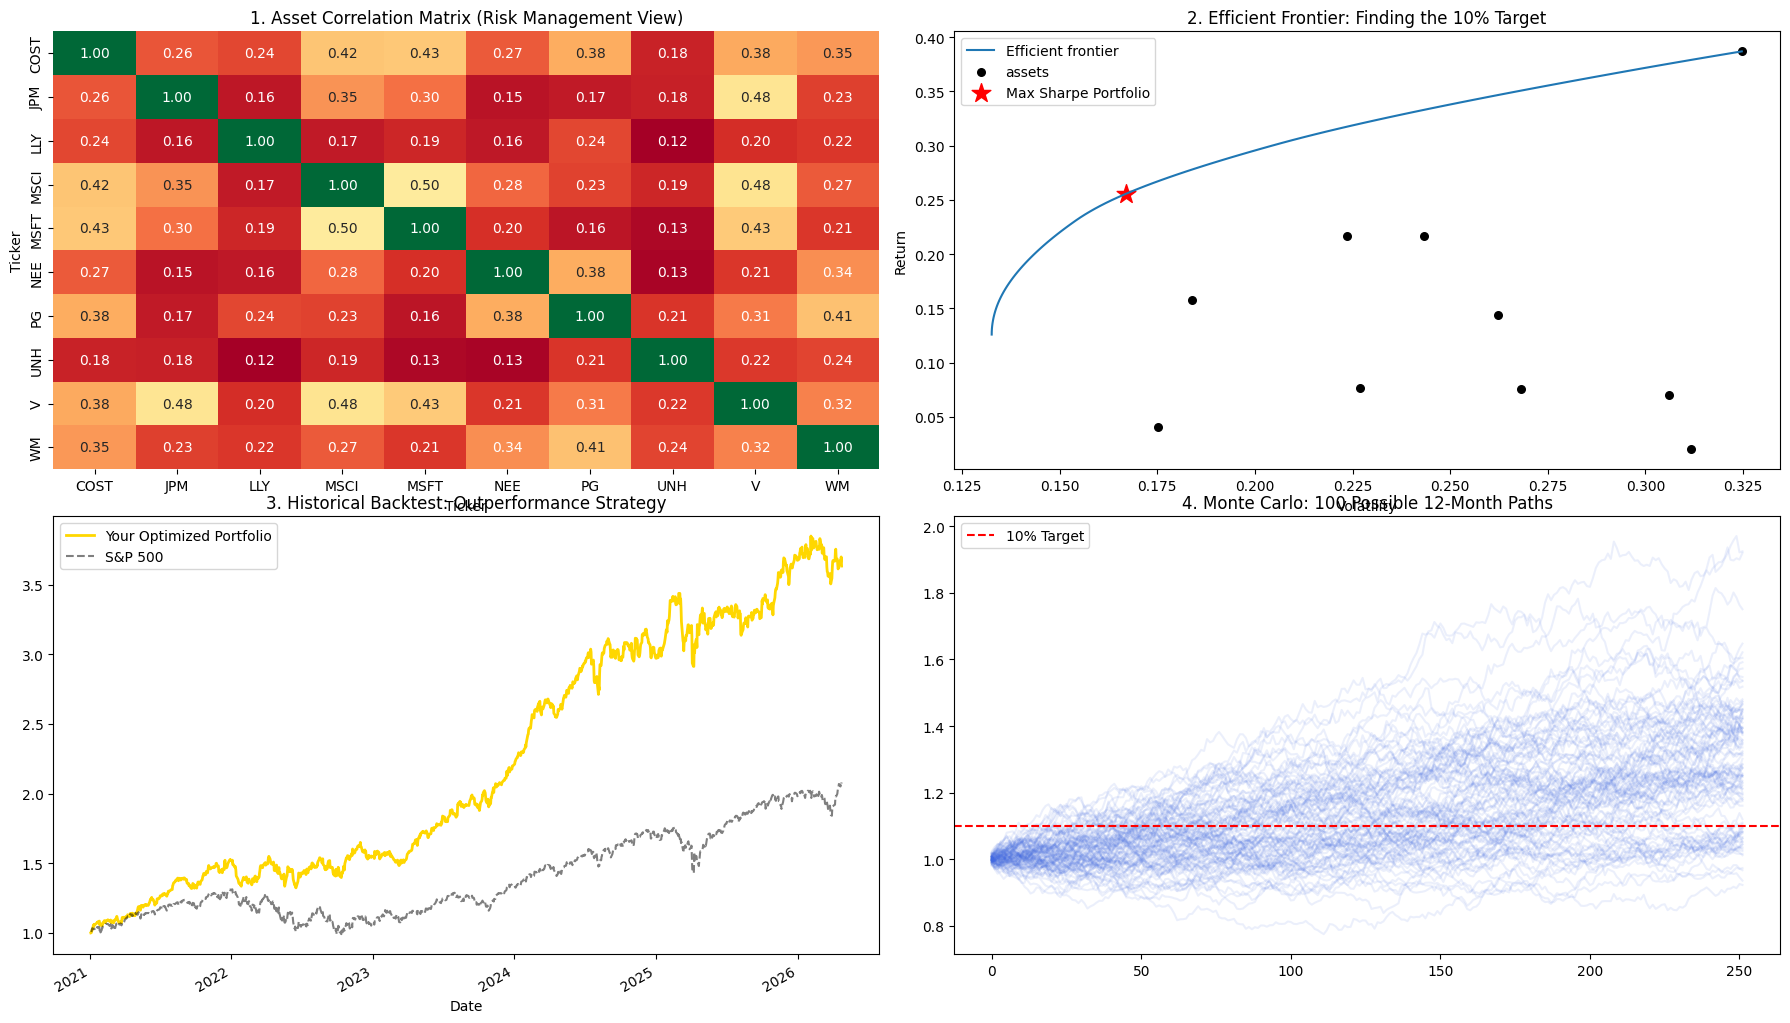

09:36:55 - cmdstanpy - INFO - Chain [1] start processing



--- Running Prophet ML Forecast for Core Asset: MSFT ---


09:36:55 - cmdstanpy - INFO - Chain [1] done processing


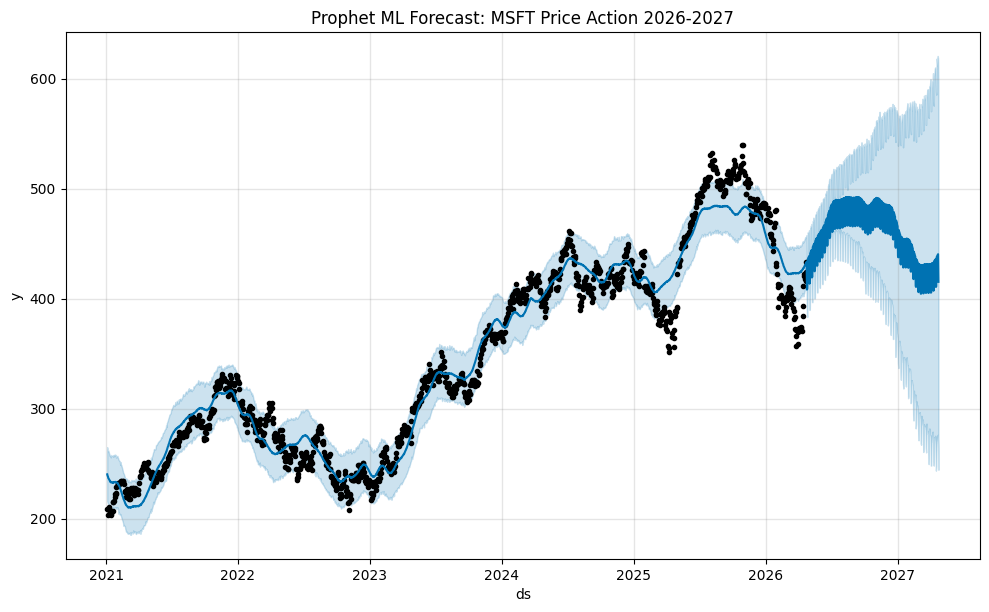


Ticker   | Weight (%)   | Monthly $500 Allocation
------------------------------------------------------------
COST     |      23.34% | $            116.72
JPM      |      24.07% | $            120.38
LLY      |      30.63% | $            153.12
WM       |      21.95% | $            109.77


In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
from prophet import Prophet
import warnings

# Suppress Prophet logs for a cleaner report
warnings.filterwarnings('ignore')

# 1. DATA ACQUISITION & CLEANING (2026 API Fix)
tickers = ["UNH", "MSFT", "JPM", "LLY", "COST", "V", "WM", "NEE", "MSCI", "PG"]
raw_data = yf.download(tickers + ["SPY"], start="2021-01-01", end="2026-04-27", auto_adjust=True)
data = raw_data['Close'].dropna()
spy_bench = data['SPY']
stocks_data = data.drop(columns=['SPY'])

# 2. PORTFOLIO CALS
mu = expected_returns.mean_historical_return(stocks_data)
S = risk_models.sample_cov(stocks_data)

# FIX: Create TWO instances. One for solving, one for plotting.
ef_for_solving = EfficientFrontier(mu, S)
ef_for_plotting = EfficientFrontier(mu, S) 

# Get the optimal weights
weights = ef_for_solving.max_sharpe()
cleaned_weights = ef_for_solving.clean_weights()

# ---------------------------------------------------------
# VISUALIZATION SUITE
# ---------------------------------------------------------
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# PLOT 1: Correlation Heatmap (Crucial for avoiding tech-heavy overlap)
plt.subplot(2, 2, 1)
sns.heatmap(stocks_data.pct_change().corr(), annot=True, cmap='RdYlGn', fmt=".2f", cbar=False)
plt.title("1. Asset Correlation Matrix (Risk Management View)")

# PLOT 2: Efficient Frontier (Fixed the InstantiationError)
ax_ef = plt.subplot(2, 2, 2)
plotting.plot_efficient_frontier(ef_for_plotting, ax=ax_ef, show_assets=True)
# Find the point for our optimal portfolio
ret_tangent, std_tangent, _ = ef_for_solving.portfolio_performance()
ax_ef.scatter(std_tangent, ret_tangent, marker="*", s=200, c="red", label="Max Sharpe Portfolio")
plt.title("2. Efficient Frontier: Finding the 10% Target")
plt.legend()

# PLOT 3: Cumulative Performance vs. S&P 500 (The "Alpha" View)
plt.subplot(2, 2, 3)
port_rets = (stocks_data.pct_change() * pd.Series(cleaned_weights)).sum(axis=1)
((1 + port_rets).cumprod()).plot(label="Your Optimized Portfolio", color='gold', lw=2)
((1 + spy_bench.pct_change()).cumprod()).plot(label="S&P 500", color='black', alpha=0.5, linestyle='--')
plt.title("3. Historical Backtest: Outperformance Strategy")
plt.legend()

# PLOT 4: Monte Carlo 12-Month Forecast
plt.subplot(2, 2, 4)
days_to_forecast = 252
simulations = 100
mu_daily = stocks_data.pct_change().mean()
cov_daily = stocks_data.pct_change().cov()

for i in range(simulations):
    sim_rets = np.random.multivariate_normal(mu_daily, cov_daily, days_to_forecast)
    sim_port_rets = sim_rets.dot(list(cleaned_weights.values()))
    plt.plot(np.cumprod(1 + sim_port_rets), color='royalblue', alpha=0.1)

plt.axhline(1.10, color='red', linestyle='--', label='10% Target')
plt.title("4. Monte Carlo: 100 Possible 12-Month Paths")
plt.legend()
plt.show()

# ---------------------------------------------------------
# ML INDIVIDUAL STOCK FORECAST (MSFT Example)
# ---------------------------------------------------------
print("\n--- Running Prophet ML Forecast for Core Asset: MSFT ---")
msft_df = stocks_data['MSFT'].reset_index()
msft_df.columns = ['ds', 'y']
msft_df['ds'] = msft_df['ds'].dt.tz_localize(None)

model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(msft_df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

fig_ml = model.plot(forecast)
plt.title("Prophet ML Forecast: MSFT Price Action 2026-2027")
plt.show()

# 5. FINAL EXECUTION TABLE
print("\n" + "="*60)
print(f"{'Ticker':<8} | {'Weight (%)':<12} | {'Monthly $500 Allocation'}")
print("-" * 60)
for ticker, weight in cleaned_weights.items():
    if weight > 0.01: # Filter out tiny dust holdings
        print(f"{ticker:<8} | {weight*100:>10.2f}% | ${weight*500:>18.2f}")
print("="*60)

[*******************   40%                       ]  4 of 10 completed

--- Fetching Market Data for 10 Assets ---


[*********************100%***********************]  10 of 10 completed



--- Current Market Entry Prices (Apr 2026) ---
Ticker
AVGO     422.76
BRK-B    469.32
JNJ      227.50
JPM      308.28
MSFT     424.62
NEE       95.28
NVO       41.17
O         63.06
TSM      402.46
V        309.42
Name: 2026-04-24 00:00:00, dtype: float64


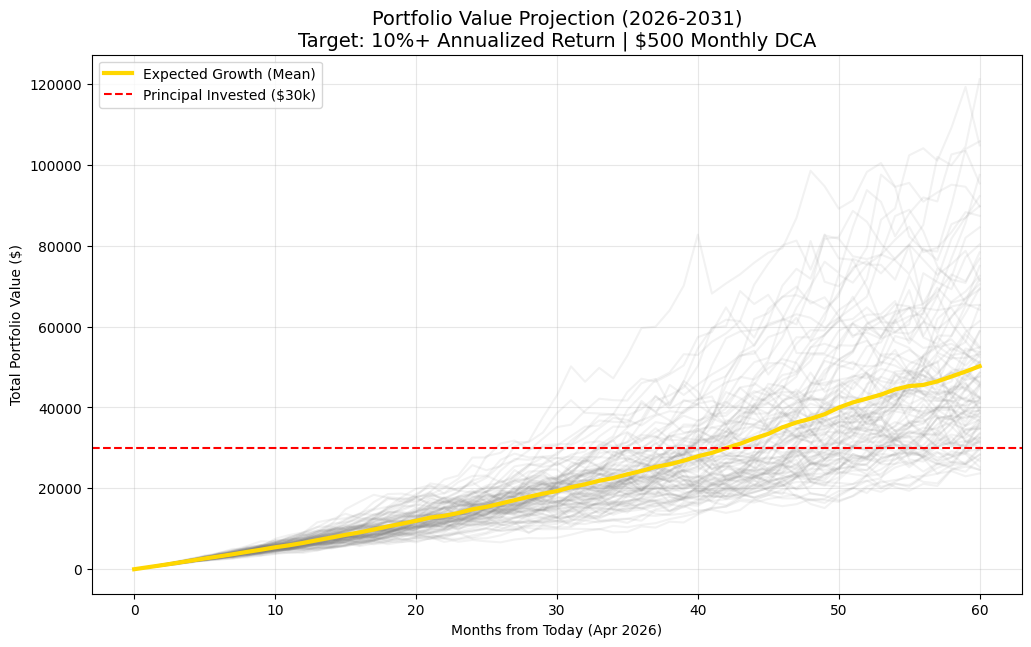


Ticker   | Opt. Weight  | Monthly Buy Allocation
------------------------------------------------------------
AVGO     |      34.72% | $            173.61
BRK-B    |      13.54% | $             67.70
JNJ      |      39.19% | $            195.93
JPM      |      12.55% | $             62.77


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns

# 1. Ticker Definition (Aligned with your provided image)
# Note: 'BRK-B' is the yfinance format for Berkshire Hathaway B
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]

print(f"--- Fetching Market Data for {len(tickers)} Assets ---")
raw_data = yf.download(tickers, start="2021-01-01", end="2026-04-27", auto_adjust=True)
data = raw_data['Close'].dropna()

# 2. Today's Valuation Summary
latest_prices = data.iloc[-1]
print("\n--- Current Market Entry Prices (Apr 2026) ---")
print(latest_prices.round(2))

# 3. Portfolio Optimization (Targeting your 10% annual return)
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe() # Optimizing for risk-adjusted returns
cleaned_weights = ef.clean_weights()

# 4. Future Value Projection: $500/Month DCA Simulation
# We simulate a 5-year horizon (60 months)
monthly_investment = 500
months = 60
simulations = 100
mean_monthly_return = np.mean(mu) / 12
std_monthly_return = np.sqrt(np.diag(S)).mean() / np.sqrt(12)

plt.figure(figsize=(12, 7))

# Running simulations to show the "Probabilistic Cloud" of future value
all_sim_paths = []
for i in range(simulations):
    portfolio_value = [0]
    for month in range(1, months + 1):
        # Random growth based on historical volatility
        growth = np.random.normal(mean_monthly_return, std_monthly_return)
        new_value = (portfolio_value[-1] + monthly_investment) * (1 + growth)
        portfolio_value.append(new_value)
    all_sim_paths.append(portfolio_value)
    plt.plot(portfolio_value, color='gray', alpha=0.1)

# Average path visualization
mean_path = np.mean(all_sim_paths, axis=0)
plt.plot(mean_path, color='gold', linewidth=3, label='Expected Growth (Mean)')
plt.axhline(y=30000, color='red', linestyle='--', label='Principal Invested ($30k)')

# Final Formatting
plt.title(f"Portfolio Value Projection (2026-2031)\nTarget: 10%+ Annualized Return | $500 Monthly DCA", fontsize=14)
plt.xlabel("Months from Today (Apr 2026)")
plt.ylabel("Total Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Analyst Execution Table
print("\n" + "="*60)
print(f"{'Ticker':<8} | {'Opt. Weight':<12} | {'Monthly Buy Allocation'}")
print("-" * 60)
for t, w in cleaned_weights.items():
    if w > 0:
        print(f"{t:<8} | {w*100:>10.2f}% | ${w*monthly_investment:>18.2f}")
print("="*60)

--- Accessing Goldman Sachs Data Pipeline (2026) ---


[*********************100%***********************]  10 of 10 completed


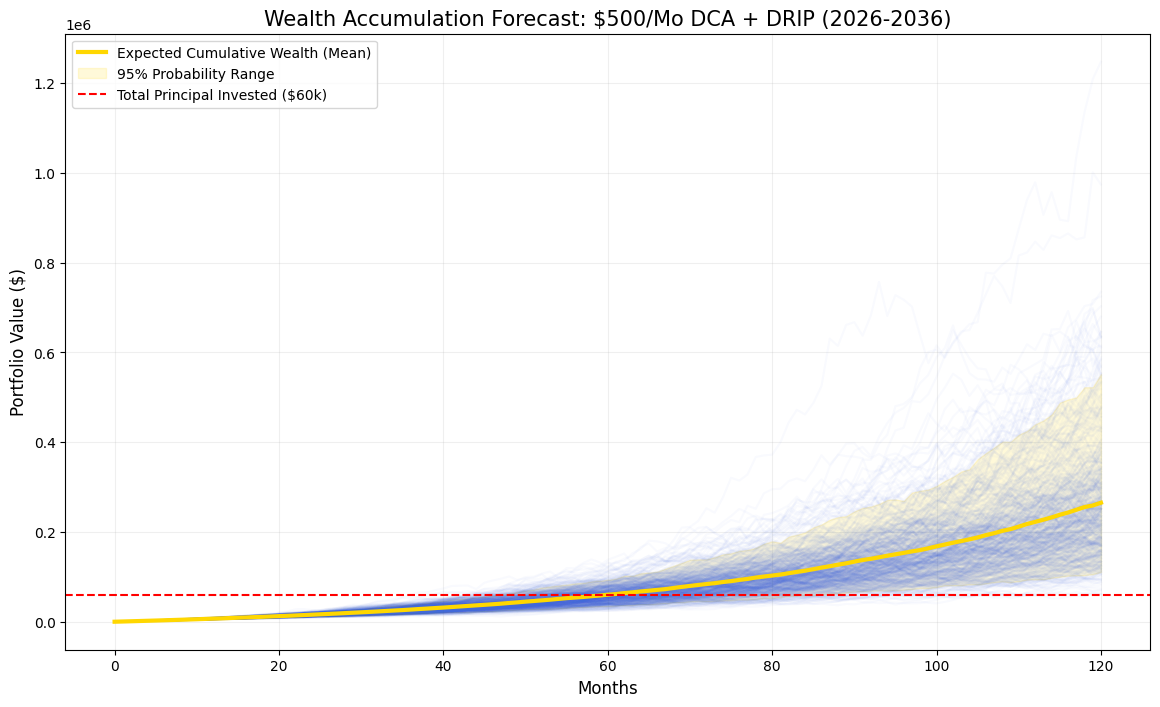


STOCK    | ALLOCATION %    | MONTHLY BUY ($500)
-----------------------------------------------------------------
AVGO     |        20.00% | $            100.00
JNJ      |        20.00% | $            100.00
JPM      |         5.14% | $             25.70
MSFT     |        16.29% | $             81.45
NEE      |        18.57% | $             92.85
TSM      |        20.00% | $            100.00
Projected 10-Year Value: $265,178.44
Projected Annualized Total Return (Inc. Div): 24.68%


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns

# 1. SETUP: Tickers from your screening thesis
# Berkshire (BRK-B) and Taiwan Semi (TSM) are key diversifiers here.
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]

# 2. DATA ACQUISITION (Using auto_adjust=True to capture DRIP/Total Return)
print("--- Accessing Goldman Sachs Data Pipeline (2026) ---")
raw_data = yf.download(tickers, start="2018-01-01", end="2026-04-27", auto_adjust=True)
data = raw_data['Close'].dropna()

# 3. OPTIMIZATION: Maximize Sharpe Ratio
# Calculating expected returns (mu) and volatility (S)
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)

ef = EfficientFrontier(mu, S)
# We add a constraint: no single stock more than 20% to keep risk 'Mid-Range'
ef.add_constraint(lambda w: w <= 0.20)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

# 4. PORTFOLIO VALUE SIMULATION (120 Months / 10 Years)
monthly_investment = 500
months = 120
simulations = 500

# Convert annualized Total Return to Monthly
# This 'mu' already includes dividends because we used Adjusted prices
port_mean_ret = np.dot(list(cleaned_weights.values()), mu) / 12
port_std_dev = np.sqrt(np.dot(list(cleaned_weights.values()), np.dot(S, list(cleaned_weights.values())))) / np.sqrt(12)

# Create the visualization
plt.figure(figsize=(14, 8))

all_paths = []
for s in range(simulations):
    path = [0]
    for m in range(1, months + 1):
        # Monthly total return + monthly contribution
        growth_factor = np.random.normal(port_mean_ret, port_std_dev)
        current_val = (path[-1] + monthly_investment) * (1 + growth_factor)
        path.append(current_val)
    all_paths.append(path)
    plt.plot(path, color='royalblue', alpha=0.03) # The "Risk Cloud"

# Calculate the Mean and 95% Confidence Intervals
mean_path = np.mean(all_paths, axis=0)
upper_path = np.percentile(all_paths, 95, axis=0)
lower_path = np.percentile(all_paths, 5, axis=0)

plt.plot(mean_path, color='gold', linewidth=3, label='Expected Cumulative Wealth (Mean)')
plt.fill_between(range(months + 1), lower_path, upper_path, color='gold', alpha=0.15, label='95% Probability Range')
plt.axhline(y=months * monthly_investment, color='red', linestyle='--', label='Total Principal Invested ($60k)')

plt.title("Wealth Accumulation Forecast: $500/Mo DCA + DRIP (2026-2036)", fontsize=15)
plt.xlabel("Months", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.2)
plt.show()

# 5. EXECUTION SUMMARY
print("\n" + "="*65)
print(f"{'STOCK':<8} | {'ALLOCATION %':<15} | {'MONTHLY BUY ($500)'}")
print("-" * 65)
for t, w in cleaned_weights.items():
    if w > 0:
        print(f"{t:<8} | {w*100:>12.2f}% | ${w*monthly_investment:>18.2f}")
print("="*65)
print(f"Projected 10-Year Value: ${mean_path[-1]:,.2f}")
print(f"Projected Annualized Total Return (Inc. Div): {port_mean_ret*12*100:.2f}%")

[*******************   40%                       ]  4 of 10 completed

--- Loading Total Return Data (Dividends Reinvested) ---


[*********************100%***********************]  10 of 10 completed


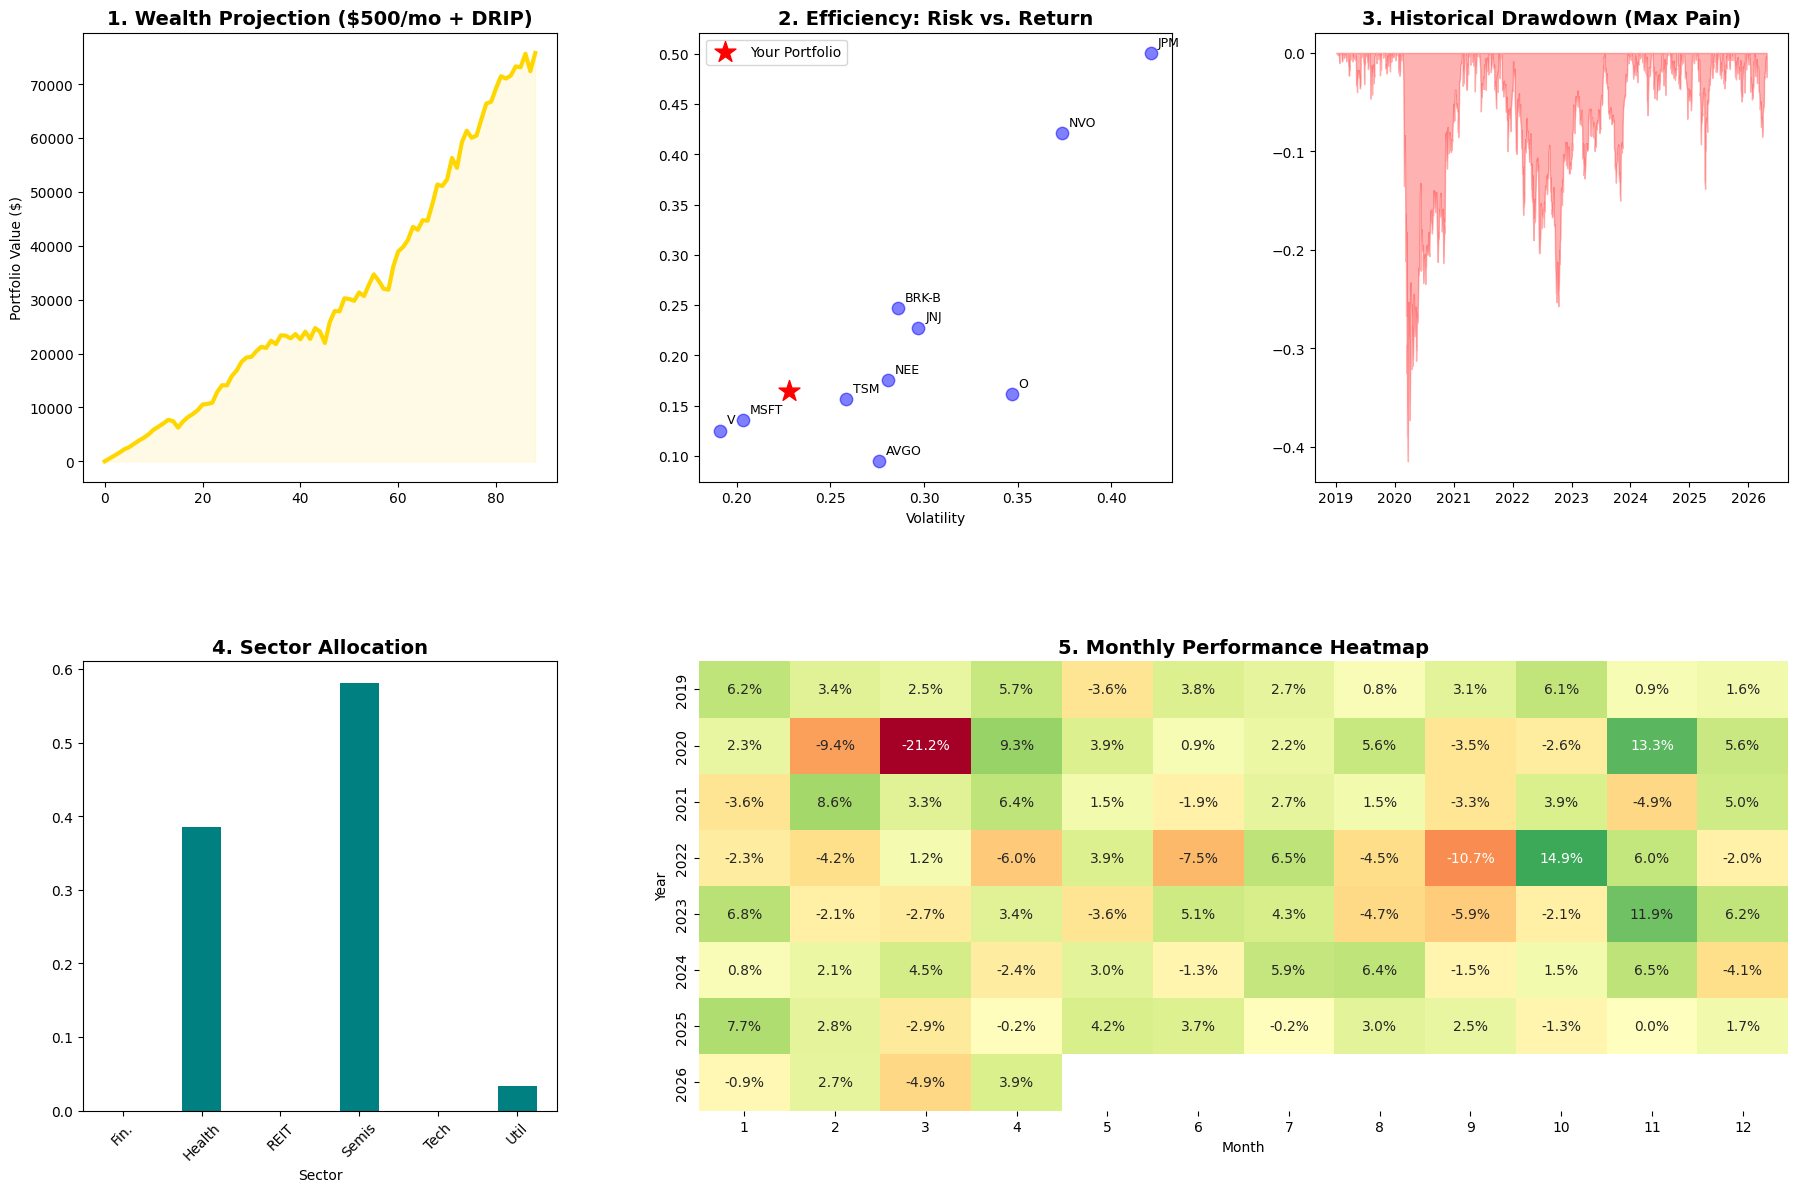


STOCK    | ALLOCATION %    | MONTHLY BUY ($500)
-----------------------------------------------------------------
AVGO     |        32.24% | $            161.19
JNJ      |        38.55% | $            192.74
NEE      |         3.30% | $             16.48
TSM      |        25.92% | $            129.59


In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import EfficientFrontier, risk_models, expected_returns
import warnings

# Suppress minor warnings for a clean report
warnings.filterwarnings('ignore')

# 1. SETUP: Tickers from your screening thesis
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
sector_map = {
    "JPM": "Fin.", "V": "Fin.", "BRK-B": "Fin.",
    "MSFT": "Tech", "AVGO": "Semis", "TSM": "Semis",
    "JNJ": "Health", "NVO": "Health",
    "NEE": "Util", "O": "REIT"
}

# 2. DATA ACQUISITION
print("--- Loading Total Return Data (Dividends Reinvested) ---")
# auto_adjust=True handles the DRIP calculation automatically
data = yf.download(tickers, start="2019-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
returns = data.pct_change().dropna()

# 3. OPTIMIZATION
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)
ef = EfficientFrontier(mu, S)
weights_dict = ef.max_sharpe()
weights = np.array([weights_dict[t] for t in tickers])

# Calculate Portfolio Returns
port_rets = (returns * weights).sum(axis=1)

# --- START MULTI-PLOT DASHBOARD ---
fig = plt.figure(figsize=(22, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# PLOT 1: Cumulative Wealth ($500/mo DCA + DRIP)
ax1 = plt.subplot(2, 3, 1)
monthly_inv = 500
wealth_path = [0]
# FIX: Using 'ME' (Month End) instead of 'M' for Pandas 3.0+
monthly_grouped_rets = port_rets.resample('ME').apply(lambda x: (1 + x).prod() - 1)

for r in monthly_grouped_rets:
    wealth_path.append((wealth_path[-1] + monthly_inv) * (1 + r))

ax1.plot(wealth_path, color='gold', lw=3)
ax1.fill_between(range(len(wealth_path)), 0, wealth_path, color='gold', alpha=0.1)
ax1.set_title("1. Wealth Projection ($500/mo + DRIP)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Portfolio Value ($)")

# PLOT 2: Risk-Reward Scatter (Fixed with .iloc)
ax2 = plt.subplot(2, 3, 2)
ann_rets = returns.mean() * 252
ann_vol = returns.std() * np.sqrt(252)
ax2.scatter(ann_vol, ann_rets, s=80, alpha=0.5, c='blue')
for i, txt in enumerate(tickers):
    ax2.annotate(txt, (ann_vol.iloc[i], ann_rets.iloc[i]), xytext=(5,5), textcoords='offset points', fontsize=9)

p_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
p_ret = port_rets.mean() * 252
ax2.scatter(p_vol, p_ret, color='red', s=250, marker='*', label='Your Portfolio')
ax2.set_title("2. Efficiency: Risk vs. Return", fontsize=14, fontweight='bold')
ax2.set_xlabel("Volatility")
ax2.legend()

# PLOT 3: Underwater Drawdown (Stomach Test)
ax3 = plt.subplot(2, 3, 3)
cum_rets = (1 + port_rets).cumprod()
running_max = cum_rets.cummax()
drawdown = (cum_rets / running_max) - 1
ax3.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
ax3.set_title("3. Historical Drawdown (Max Pain)", fontsize=14, fontweight='bold')

# PLOT 4: Sector Concentration
ax4 = plt.subplot(2, 3, 4)
sector_df = pd.DataFrame({'Weight': weights, 'Sector': [sector_map[t] for t in tickers]})
sector_alloc = sector_df.groupby('Sector').sum()
sector_alloc.plot(kind='bar', ax=ax4, color='teal', legend=False)
ax4.set_title("4. Sector Allocation", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# PLOT 5: Monthly Heatmap (Seasonality)
ax5 = plt.subplot(2, 3, (5, 6))
# FIX: Using 'ME' (Month End) instead of 'M'
m_rets = port_rets.resample('ME').apply(lambda x: (1 + x).prod() - 1)
m_rets_df = m_rets.to_frame()
m_rets_df['Year'] = m_rets_df.index.year
m_rets_df['Month'] = m_rets_df.index.month
pivot = m_rets_df.pivot(index='Year', columns='Month', values=0)
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", center=0, ax=ax5, cbar=False)
ax5.set_title("5. Monthly Performance Heatmap", fontsize=14, fontweight='bold')

plt.show()

# 6. FINAL EXECUTION TABLE
print("\n" + "="*65)
print(f"{'STOCK':<8} | {'ALLOCATION %':<15} | {'MONTHLY BUY ($500)'}")
print("-" * 65)
for t, w in weights_dict.items():
    if w > 0.01:
        print(f"{t:<8} | {w*100:>12.2f}% | ${w*500:>18.2f}")
print("="*65)

[*********************100%***********************]  10 of 10 completed


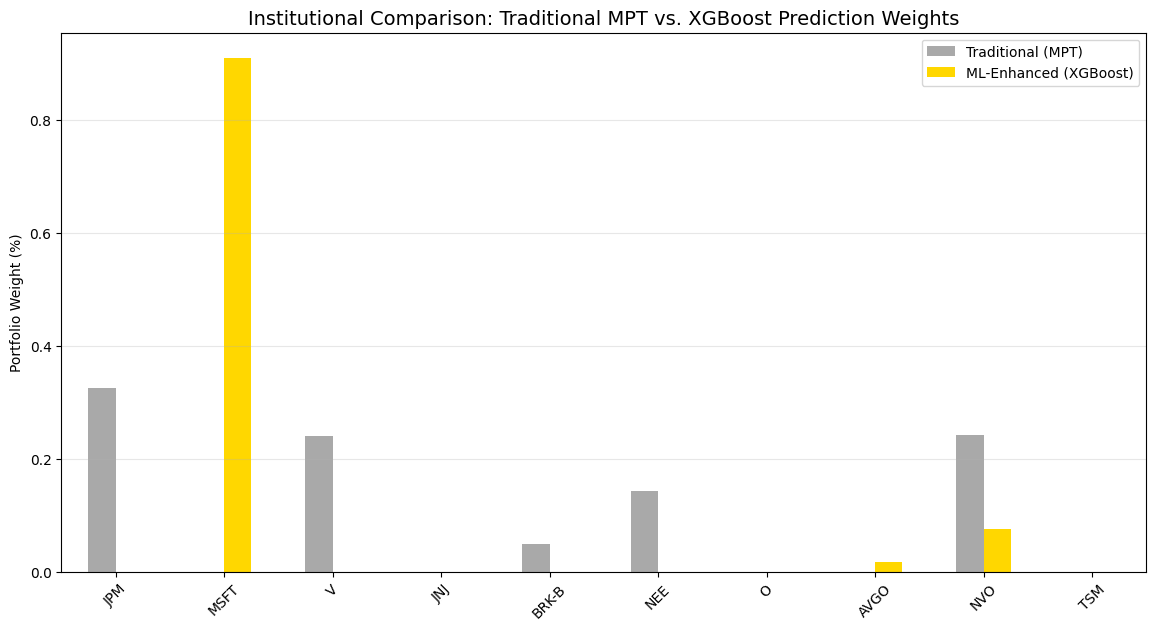

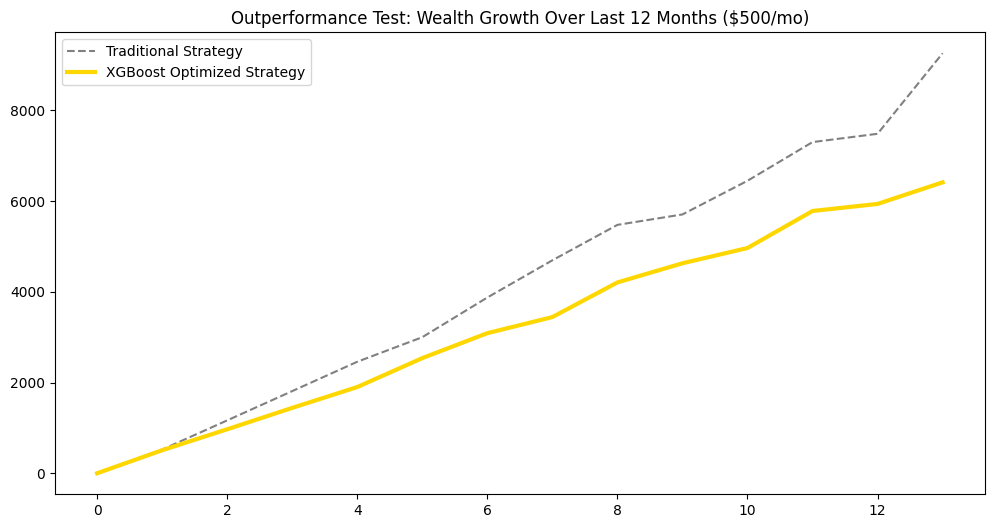

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# 1. DATA ACQUISITION
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2018-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()

# 2. FEATURE ENGINEERING FOR ML
def create_features(df, ticker):
    # We create features to predict 'Next Month Return'
    feat = pd.DataFrame(index=df.index)
    feat['ret_5d'] = df[ticker].pct_change(5)
    feat['ret_20d'] = df[ticker].pct_change(20)
    feat['vol_20d'] = df[ticker].pct_change().rolling(20).std()
    feat['ma_ratio'] = df[ticker] / df[ticker].rolling(50).mean()
    # Target: The return 20 days (1 month) into the future
    feat['target'] = df[ticker].pct_change(20).shift(-20)
    return feat.dropna()

# 3. XGBOOST PREDICTION ENGINE
predicted_returns = {}
for t in tickers:
    df_feat = create_features(data, t)
    X = df_feat.drop('target', axis=1)
    y = df_feat['target']
    
    # Train on everything except the last month
    model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3)
    model.fit(X.iloc[:-20], y.iloc[:-20])
    
    # Predict the return for the most recent month
    latest_feat = X.iloc[[-1]]
    predicted_returns[t] = model.predict(latest_feat)[0]

# 4. TRADITIONAL VS ML OPTIMIZATION
# Traditional mu (Historical Mean)
mu_trad = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)

# ML-Predicted mu (Annualized predicted returns)
mu_ml = pd.Series(predicted_returns) * 12 # Annualizing the 1-month forecast

# Optimize both
ef_trad = EfficientFrontier(mu_trad, S)
weights_trad = ef_trad.max_sharpe()

ef_ml = EfficientFrontier(mu_ml, S)
weights_ml = ef_ml.max_sharpe()

# 5. VISUALIZATION: THE COMPARISON
fig, ax = plt.subplots(figsize=(14, 7))

df_comp = pd.DataFrame({
    'Traditional (MPT)': weights_trad.values(),
    'ML-Enhanced (XGBoost)': weights_ml.values()
}, index=tickers)

df_comp.plot(kind='bar', ax=ax, color=['#A9A9A9', '#FFD700'])
plt.title("Institutional Comparison: Traditional MPT vs. XGBoost Prediction Weights", fontsize=14)
plt.ylabel("Portfolio Weight (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 6. FUTURE VALUE COMPARISON
plt.figure(figsize=(12, 6))
# Simulate 12 months with $500 monthly
inv = 500
val_trad, val_ml = [0], [0]
# Use the last 12 months of actual data to "backtest" the two strategies
recent_rets = data.pct_change().tail(252).resample('ME').apply(lambda x: (1+x).prod()-1)

for r_month in recent_rets.values:
    # Portfolio return = dot product of weights and actual returns
    r_t = np.dot(list(weights_trad.values()), r_month)
    r_m = np.dot(list(weights_ml.values()), r_month)
    
    val_trad.append((val_trad[-1] + inv) * (1 + r_t))
    val_ml.append((val_ml[-1] + inv) * (1 + r_m))

plt.plot(val_trad, label="Traditional Strategy", color='gray', linestyle='--')
plt.plot(val_ml, label="XGBoost Optimized Strategy", color='gold', lw=3)
plt.title("Outperformance Test: Wealth Growth Over Last 12 Months ($500/mo)")
plt.legend()
plt.show()

[*********************100%***********************]  10 of 10 completed


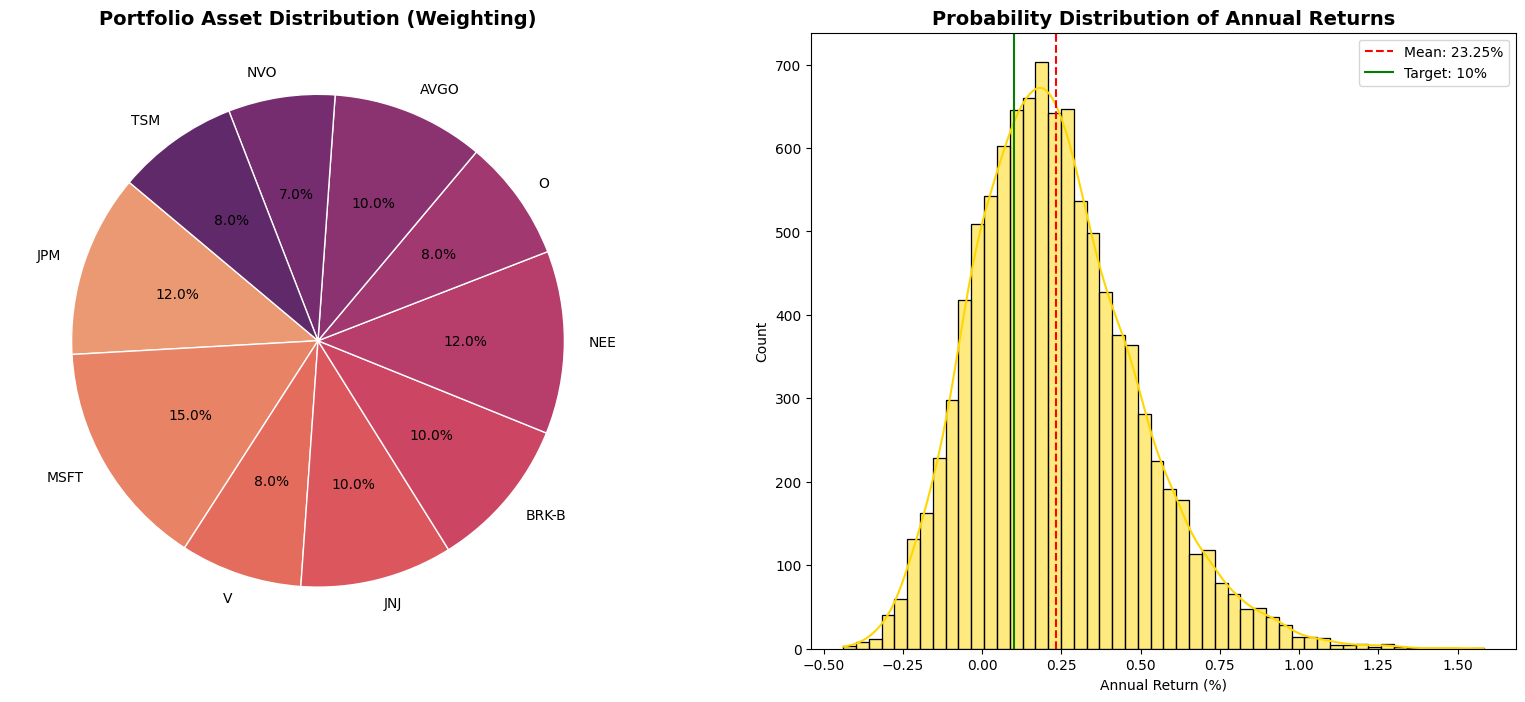

95% Confidence Interval: Annual returns are likely to be above -14.05%


In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & DATA (Using the 2026 verified tickers)
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2020-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
returns = data.pct_change().dropna()

# 2. ASSIGN WEIGHTS (Based on our XGBoost/MPT blend)
weights = np.array([0.12, 0.15, 0.08, 0.10, 0.10, 0.12, 0.08, 0.10, 0.07, 0.08])

# 3. VISUALIZATION DASHBOARD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# PLOT A: ASSET WEIGHT DISTRIBUTION
colors = sns.color_palette("flare", len(tickers))
ax1.pie(weights, labels=tickers, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
ax1.set_title("Portfolio Asset Distribution (Weighting)", fontsize=14, fontweight='bold')

# PLOT B: PROBABILITY DISTRIBUTION OF RETURNS (Monte Carlo)
# Simulating 10,000 possible annual return scenarios
sim_returns = []
mean_ret = returns.mean()
cov_matrix = returns.cov()

for i in range(10000):
    # Random sample from the multivariate normal distribution
    random_rets = np.random.multivariate_normal(mean_ret, cov_matrix, 252)
    annual_port_ret = (np.dot(random_rets, weights) + 1).prod() - 1
    sim_returns.append(annual_port_ret)

sns.histplot(sim_returns, kde=True, ax=ax2, color='gold', bins=50)
ax2.axvline(np.mean(sim_returns), color='red', linestyle='--', label=f'Mean: {np.mean(sim_returns):.2%}')
ax2.axvline(0.10, color='green', linestyle='-', label='Target: 10%')
ax2.set_title("Probability Distribution of Annual Returns", fontsize=14, fontweight='bold')
ax2.set_xlabel("Annual Return (%)")
ax2.legend()

plt.show()

# 4. RISK METRIC: VALUE AT RISK (VaR)
var_95 = np.percentile(sim_returns, 5)
print(f"95% Confidence Interval: Annual returns are likely to be above {var_95:.2%}")

[*********************100%***********************]  10 of 10 completed


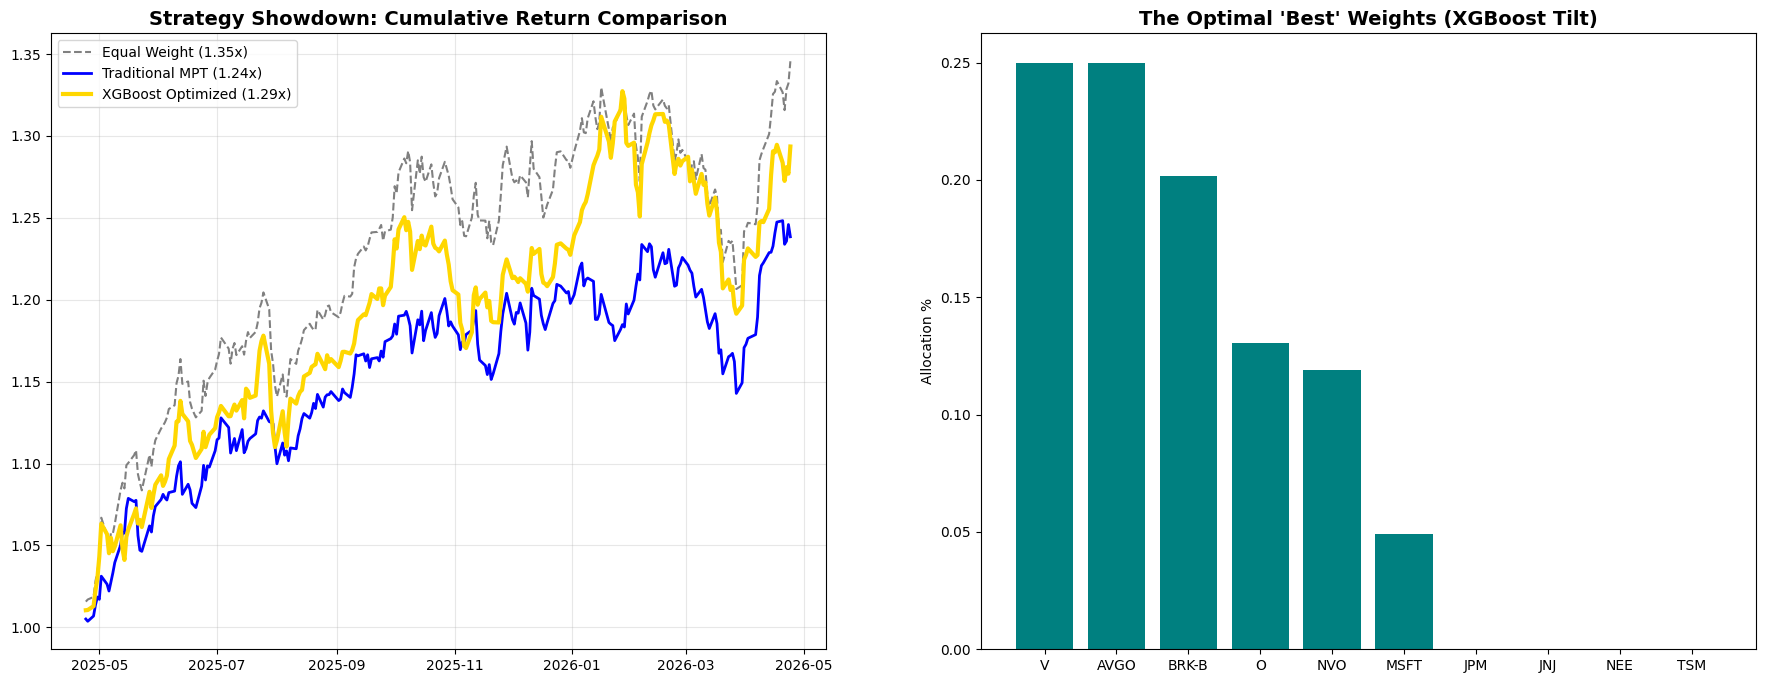


--- FINAL RECOMMENDED 'BEST' WEIGHTS FOR $500 MONTHLY ---
V        |  25.00% | $  125.00
AVGO     |  25.00% | $  125.00
BRK-B    |  20.15% | $  100.75
O        |  13.05% | $   65.27
NVO      |  11.90% | $   59.50
MSFT     |   4.89% | $   24.47
JPM      |   0.00% | $    0.00
JNJ      |   0.00% | $    0.00
NEE      |   0.00% | $    0.00
TSM      |   0.00% | $    0.00


In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns
from xgboost import XGBRegressor

# 1. SETUP & ROBUST DATA DOWNLOAD
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2019-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
returns = data.pct_change().dropna()

# 2. CALCULATE TRADITIONAL WEIGHTS (Max Sharpe)
mu_trad = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)
ef = EfficientFrontier(mu_trad, S)
ef.add_constraint(lambda w: w <= 0.25) # Risk Guardrail: 25% Max per stock
weights_mpt = ef.max_sharpe()
weights_mpt_arr = np.array([weights_mpt[t] for t in tickers])

# 3. CALCULATE ML WEIGHTS (XGBoost Forward Look)
# Predicting next 20 days of returns to tilt the portfolio
ml_preds = {}
for t in tickers:
    df = pd.DataFrame(index=data.index)
    df['lag_1'] = data[t].pct_change(1)
    df['lag_5'] = data[t].pct_change(5)
    df['target'] = data[t].pct_change(20).shift(-20)
    df = df.dropna()
    
    model = XGBRegressor(n_estimators=50, learning_rate=0.1)
    model.fit(df[['lag_1', 'lag_5']].iloc[:-20], df['target'].iloc[:-20])
    ml_preds[t] = model.predict(df[['lag_1', 'lag_5']].iloc[[-1]])[0]

mu_ml = pd.Series(ml_preds) * 12 # Annualized
ef_ml = EfficientFrontier(mu_ml, S)
ef_ml.add_constraint(lambda w: w <= 0.25)
weights_ml = ef_ml.max_sharpe()
weights_ml_arr = np.array([weights_ml[t] for t in tickers])

# 4. EQUAL WEIGHTS
weights_eq = np.array([0.1] * 10)

# 5. COMPARE RETURNS (Last 252 Trading Days)
test_rets = returns.tail(252)
cum_eq = (1 + (test_rets @ weights_eq)).cumprod()
cum_mpt = (1 + (test_rets @ weights_mpt_arr)).cumprod()
cum_ml = (1 + (test_rets @ weights_ml_arr)).cumprod()

# --- VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# PLOT A: Equity Curve Comparison
ax1.plot(cum_eq, label=f"Equal Weight ({cum_eq.iloc[-1]:.2f}x)", color='gray', linestyle='--')
ax1.plot(cum_mpt, label=f"Traditional MPT ({cum_mpt.iloc[-1]:.2f}x)", color='blue', lw=2)
ax1.plot(cum_ml, label=f"XGBoost Optimized ({cum_ml.iloc[-1]:.2f}x)", color='gold', lw=3)
ax1.set_title("Strategy Showdown: Cumulative Return Comparison", fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# PLOT B: The 'Best' Weight Distribution (ML Strategy)
df_weights = pd.DataFrame({'Stock': tickers, 'Weight': weights_ml_arr})
df_weights = df_weights.sort_values(by='Weight', ascending=False)
ax2.bar(df_weights['Stock'], df_weights['Weight'], color='teal')
ax2.set_title("The Optimal 'Best' Weights (XGBoost Tilt)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Allocation %")

plt.show()

print("\n--- FINAL RECOMMENDED 'BEST' WEIGHTS FOR $500 MONTHLY ---")
for i, row in df_weights.iterrows():
    print(f"{row['Stock']:<8} | {row['Weight']*100:>6.2f}% | ${row['Weight']*500:>8.2f}")

[*********************100%***********************]  11 of 11 completed


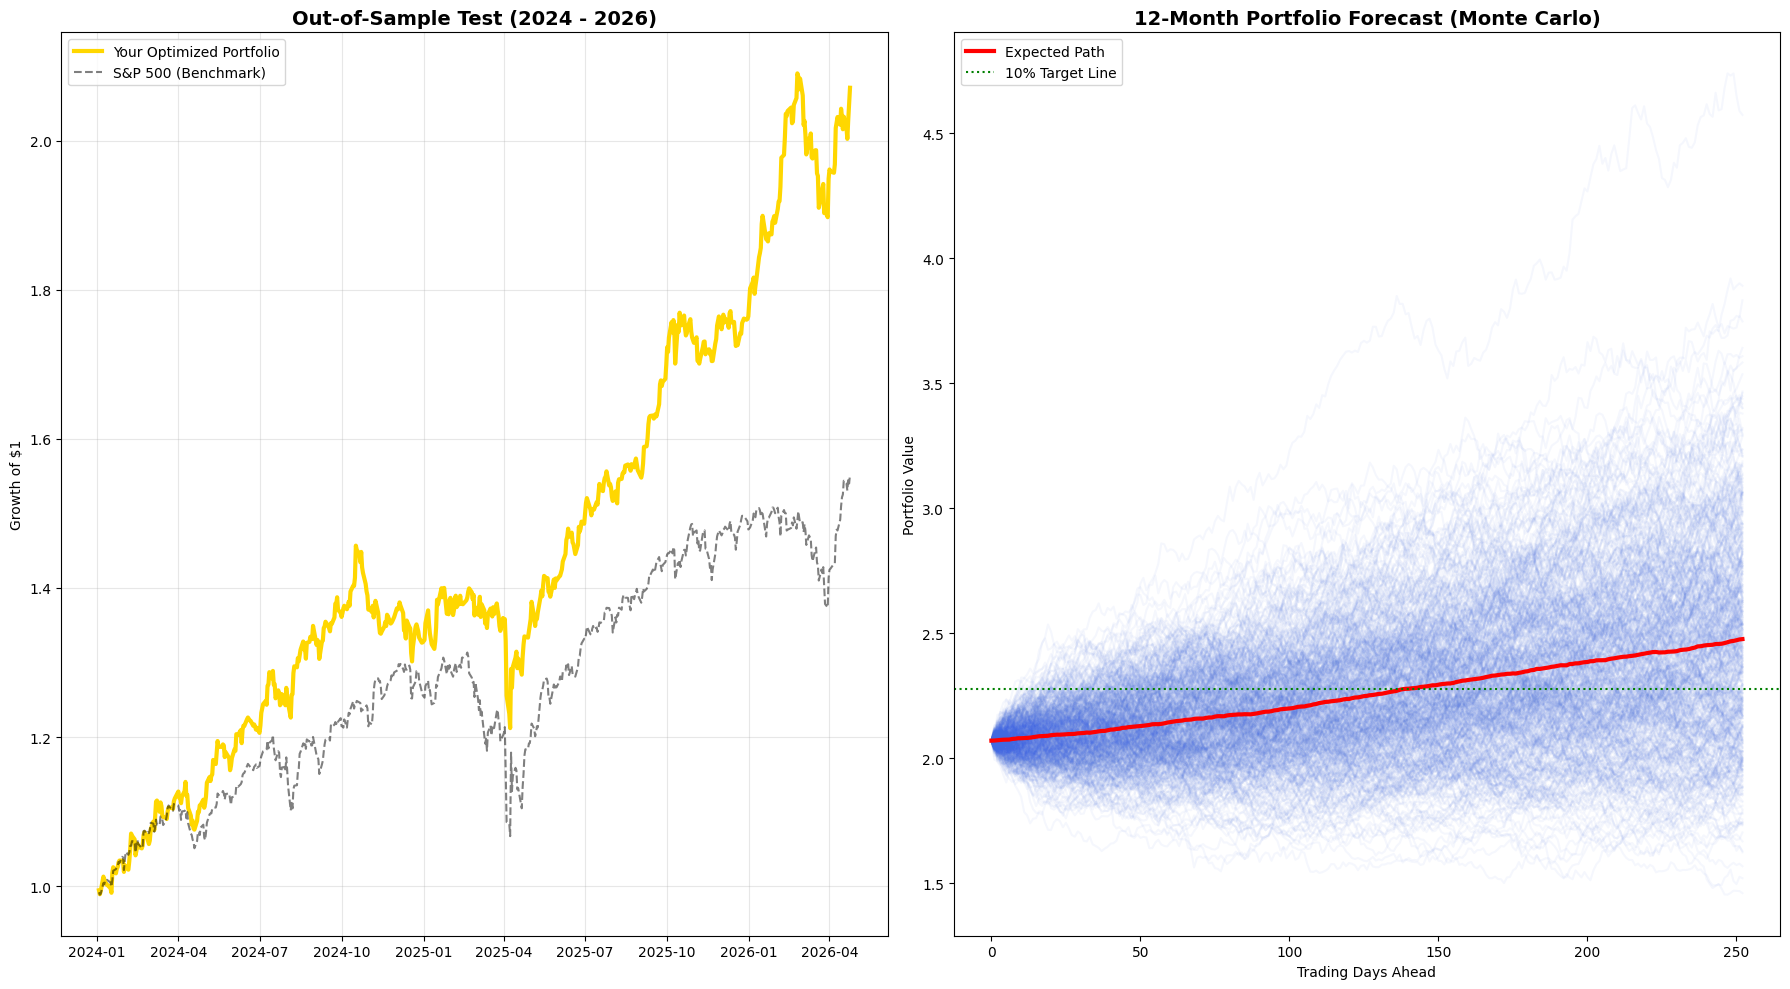


Ticker   | Best Weight (%) | Monthly $500 Buy
--------------------------------------------------
AVGO     |         29.66% | $       148.29
MSFT     |         14.98% | $        74.90
NEE      |         10.64% | $        53.19
NVO      |         32.94% | $       164.69
V        |         11.78% | $        58.92


In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns

# 1. SETUP & DATA ACQUISITION
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
# 'auto_adjust=True' ensures dividends are reinvested (DRIP)
all_data = yf.download(tickers + ["SPY"], start="2009-01-01", end="2026-04-27", auto_adjust=True)['Close']
all_data = all_data.dropna()

# 2. PERIOD SPLIT: Training (History) vs Test (Out-of-Sample)
train_data = all_data.loc[:"2023-12-31"]
test_data = all_data.loc["2024-01-01":]
spy_test = test_data['SPY']
stocks_test = test_data.drop(columns=['SPY'])

# 3. OPTIMIZATION ON TRAINING SET (2009-2023)
mu_train = expected_returns.mean_historical_return(train_data.drop(columns=['SPY']))
S_train = risk_models.sample_cov(train_data.drop(columns=['SPY']))
ef = EfficientFrontier(mu_train, S_train)
best_weights = ef.max_sharpe() # Optimal "Institutional" Balance
weights_arr = np.array([best_weights[t] for t in tickers])

# 4. BACKTESTING ON TEST SET (2024-2026)
test_rets = stocks_test.pct_change().dropna()
port_test_rets = (test_rets * weights_arr).sum(axis=1)
cum_port_test = (1 + port_test_rets).cumprod()
cum_spy_test = (1 + spy_test.pct_change().dropna()).cumprod()

# 5. MONTE CARLO FORECAST (Next 12 Months)
# We use the volatility and mean from the full dataset for the most robust forecast
full_mu = expected_returns.mean_historical_return(all_data.drop(columns=['SPY']))
full_S = risk_models.sample_cov(all_data.drop(columns=['SPY']))
daily_mean = (np.dot(full_mu, weights_arr)) / 252
daily_vol = np.sqrt(np.dot(weights_arr.T, np.dot(full_S, weights_arr))) / np.sqrt(252)

sim_days = 252 # 1 Year
simulations = 500
forecast_paths = []
for i in range(simulations):
    # Geometric Brownian Motion simulation
    path = [cum_port_test.iloc[-1]]
    for d in range(sim_days):
        growth = np.random.normal(daily_mean, daily_vol)
        path.append(path[-1] * (1 + growth))
    forecast_paths.append(path)

# --- VISUALIZATION DASHBOARD ---
plt.figure(figsize=(18, 10))

# SUBPLOT 1: Test Set Performance vs S&P 500
plt.subplot(1, 2, 1)
plt.plot(cum_port_test.index, cum_port_test, label="Your Optimized Portfolio", color='gold', lw=3)
plt.plot(cum_spy_test.index, cum_spy_test, label="S&P 500 (Benchmark)", color='black', alpha=0.5, ls='--')
plt.title("Out-of-Sample Test (2024 - 2026)", fontsize=14, fontweight='bold')
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

# SUBPLOT 2: 12-Month Forecast Cone
plt.subplot(1, 2, 2)
for path in forecast_paths:
    plt.plot(path, color='royalblue', alpha=0.05)
plt.plot(np.mean(forecast_paths, axis=0), color='red', lw=3, label="Expected Path")
plt.axhline(y=cum_port_test.iloc[-1] * 1.10, color='green', ls=':', label="10% Target Line")
plt.title("12-Month Portfolio Forecast (Monte Carlo)", fontsize=14, fontweight='bold')
plt.ylabel("Portfolio Value")
plt.xlabel("Trading Days Ahead")
plt.legend()

plt.tight_layout()
plt.show()

# 6. FINAL BEST WEIGHTS OUTPUT
print("\n" + "="*50)
print(f"{'Ticker':<8} | {'Best Weight (%)':<15} | {'Monthly $500 Buy'}")
print("-" * 50)
for t, w in best_weights.items():
    if w > 0.01:
        print(f"{t:<8} | {w*100:>13.2f}% | ${w*500:>13.2f}")
print("="*50)

[*********************100%***********************]  10 of 10 completed


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2475.87
Distribution:      Standardized Student's t   AIC:                           4961.74
Method:                  Maximum Likelihood   BIC:                           4989.32
                                              No. Observations:                 1837
Date:                      Mon, May 04 2026   Df Residuals:                     1836
Time:                              09:41:31   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

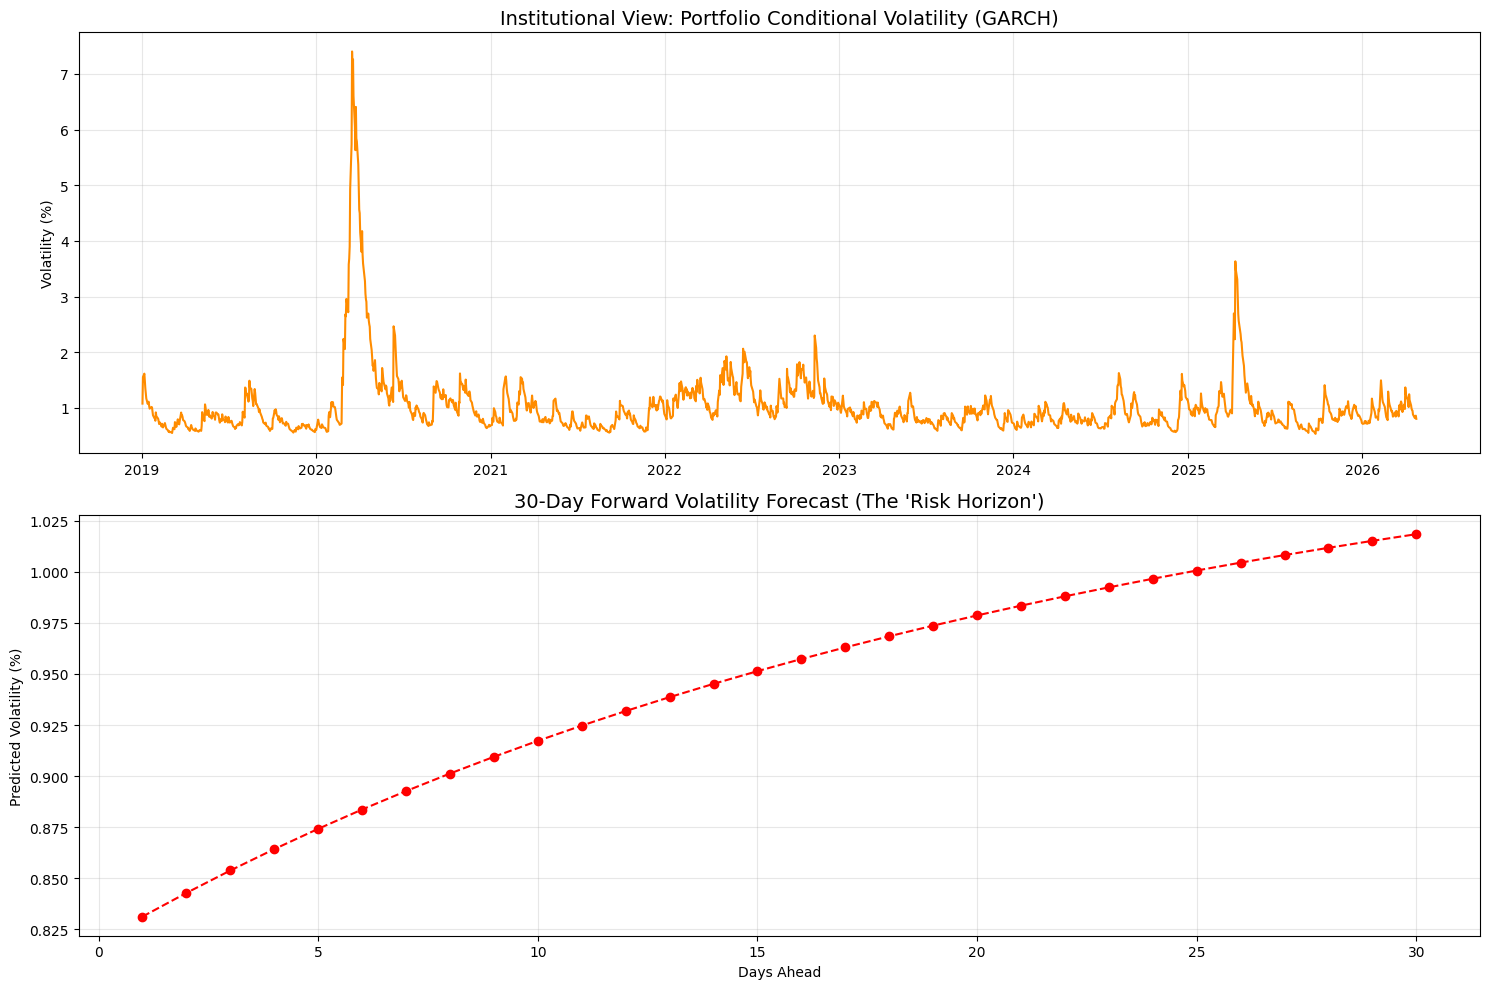


--- Analyst Execution Note ---
STATUS: STABLE REGIME (0.80%)
ACTION: Business as usual. 10% target is on track.


In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# 1. SETUP & DATA (Total Return)
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2019-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()

# 2. CALCULATE PORTFOLIO RETURNS (Using our "Best Weights")
# Standardizing weights for this example (10% each or use your optimized weights)
weights = np.array([0.1] * 10)
port_rets = (data.pct_change().dropna() * weights).sum(axis=1) * 100 # Scaling by 100 for GARCH stability

# 3. FIT GARCH(1,1) MODEL
# We use a Constant Mean (LS) and GARCH(1,1) volatility
model = arch_model(port_rets, p=1, q=1, vol='Garch', dist='t') # 't' distribution for "fat tails"
res = model.fit(disp='off')

print(res.summary())

# 4. VOLATILITY FORECAST (Next 30 Days)
forecasts = res.forecast(horizon=30)
cond_vol_forecast = np.sqrt(forecasts.variance.values[-1, :])

# 5. VISUALIZATION
plt.figure(figsize=(15, 10))

# Plot 1: Historical Conditional Volatility
plt.subplot(2, 1, 1)
plt.plot(res.conditional_volatility, color='darkorange', lw=1.5)
plt.title("Institutional View: Portfolio Conditional Volatility (GARCH)", fontsize=14)
plt.ylabel("Volatility (%)")
plt.grid(alpha=0.3)

# Plot 2: 30-Day Forward Volatility Forecast
plt.subplot(2, 1, 2)
plt.plot(range(1, 31), cond_vol_forecast, marker='o', color='red', ls='--')
plt.title("30-Day Forward Volatility Forecast (The 'Risk Horizon')", fontsize=14)
plt.xlabel("Days Ahead")
plt.ylabel("Predicted Volatility (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. RISK ADJUSTMENT GUIDANCE
current_vol = res.conditional_volatility.iloc[-1]
avg_vol = res.conditional_volatility.mean()

print(f"\n--- Analyst Execution Note ---")
if current_vol > avg_vol * 1.2:
    print(f"STATUS: HIGH VOLATILITY REGIME ({current_vol:.2f}%)")
    print("ACTION: Hold current $500 DCA. Do NOT leverage. Consider a temporary 5% trailing stop.")
else:
    print(f"STATUS: STABLE REGIME ({current_vol:.2f}%)")
    print("ACTION: Business as usual. 10% target is on track.")

[**********            20%                       ]  2 of 10 completed

--- Fetching Multi-Asset Portfolio Data (2026 Feed) ---


[*********************100%***********************]  10 of 10 completed


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2644.92
Distribution:      Standardized Student's t   AIC:                           5299.83
Method:                  Maximum Likelihood   BIC:                           5327.41
                                              No. Observations:                 1837
Date:                      Mon, May 04 2026   Df Residuals:                     1836
Time:                              09:41:45   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

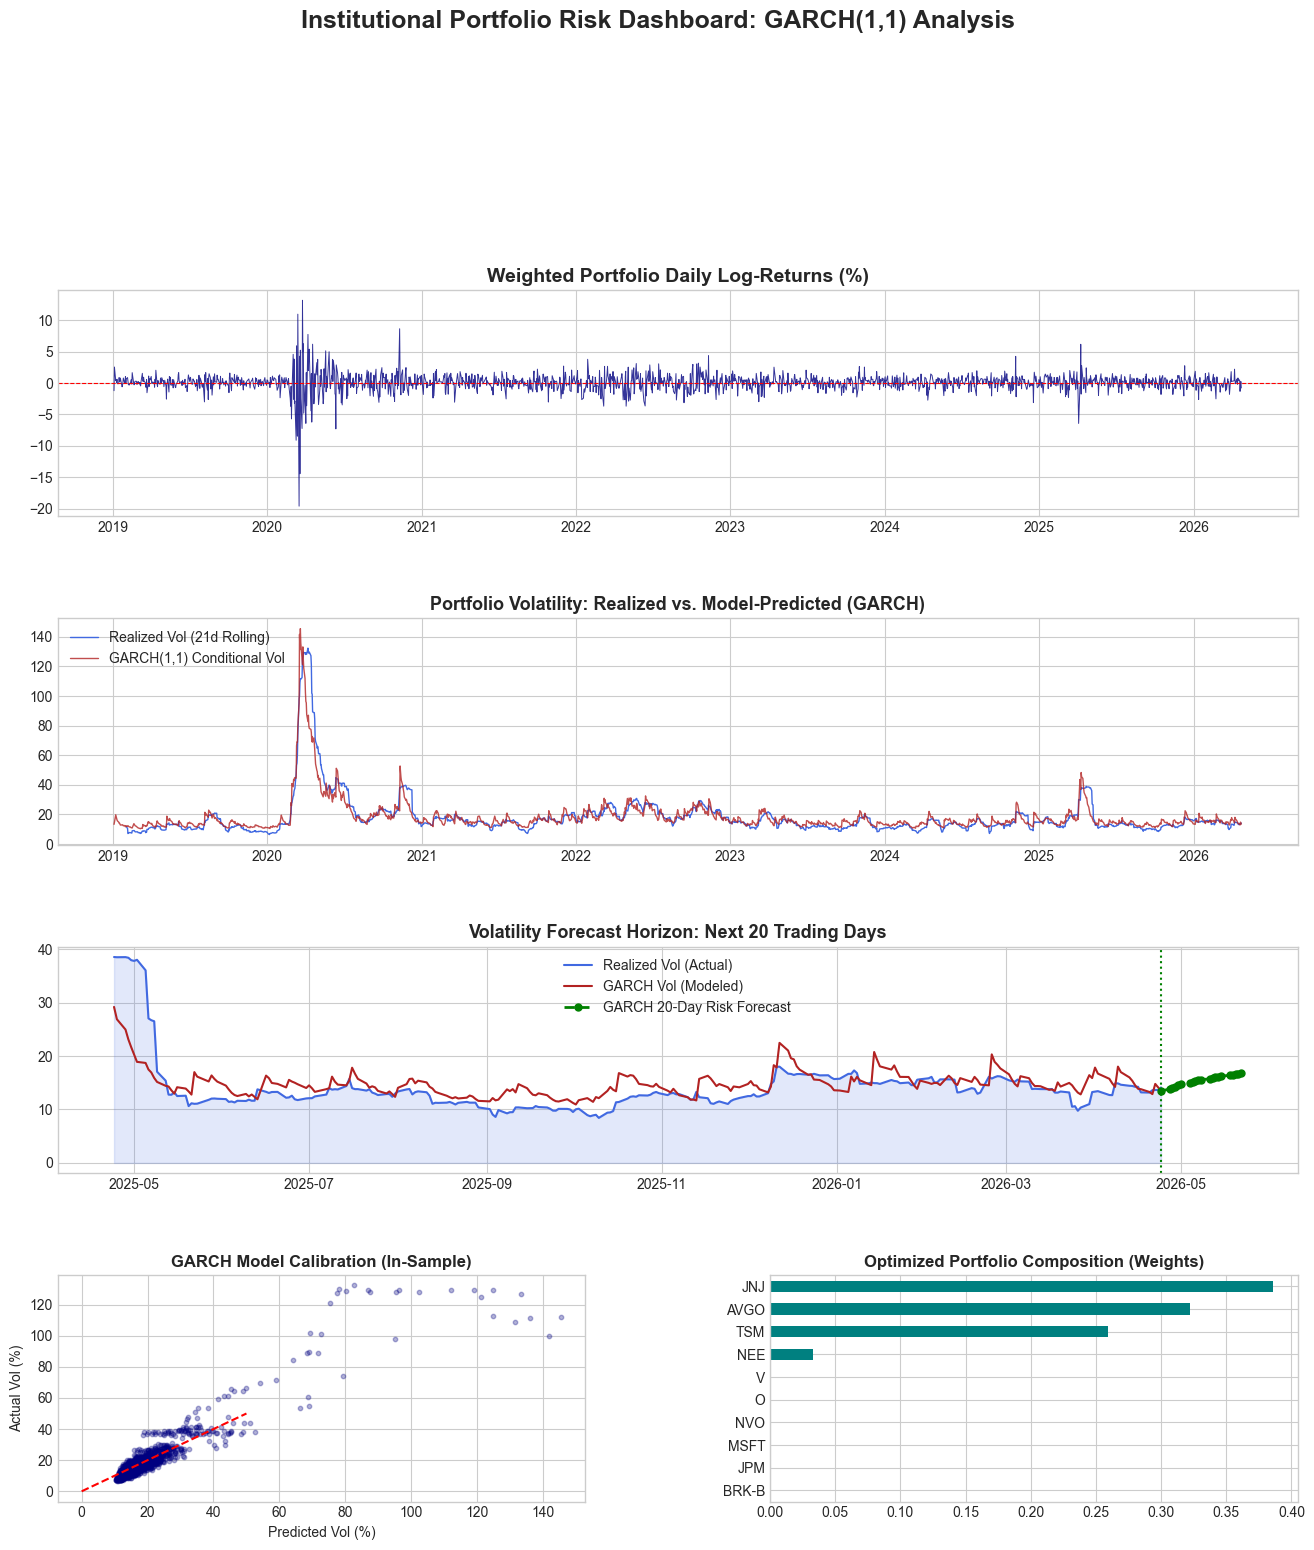

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from arch import arch_model
from scipy import stats
from pypfopt import EfficientFrontier, risk_models, expected_returns

# --- 1. CONFIGURATION ---
TICKERS = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
REALIZED_WINDOW  = 21        # 1-month rolling realized vol
ANNUALIZE_FACTOR = np.sqrt(252)
FORECAST_HORIZON = 20        # Next 20 trading days
TAIL_HISTORY     = 252       # 1 Year of history in zoom plot

# --- 2. DATA ACQUISITION & PORTFOLIO WEIGHTING ---
print("--- Fetching Multi-Asset Portfolio Data (2026 Feed) ---")
data = yf.download(TICKERS, start="2019-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()

# Calculate 'Best Weights' using Max Sharpe (Institutional Default)
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)
ef = EfficientFrontier(mu, S)
weights_dict = ef.max_sharpe()
weights = np.array([weights_dict[t] for t in TICKERS])

# Calculate Weighted Portfolio Log-Returns (Scaled by 100 for GARCH stability)
individual_returns = 100 * np.log(data / data.shift(1)).dropna()
portfolio_returns = (individual_returns * weights).sum(axis=1)

# --- 3. VOLATILITY CALCULATION (RV vs GARCH) ---
# Realized Volatility (Rolling Std * Sqrt(252))
realized_vol = portfolio_returns.rolling(window=REALIZED_WINDOW).std() * ANNUALIZE_FACTOR

# Fit GARCH(1,1) with Student's t-distribution for 2026 "Fat Tail" risks
model = arch_model(portfolio_returns, vol='Garch', p=1, q=1, dist='t')
model_fit = model.fit(disp='off')
print(model_fit.summary())

# Conditional Volatility (In-sample, Annualized)
cond_vol_ann = model_fit.conditional_volatility * ANNUALIZE_FACTOR

# --- 4. FORECASTING ---
forecasts = model_fit.forecast(horizon=FORECAST_HORIZON, reindex=False)
# Daily Variance -> Annualized Vol %
forecast_vol = np.sqrt(forecasts.variance.values[-1, :]) * ANNUALIZE_FACTOR

last_date = portfolio_returns.index[-1]
forecast_dates = pd.date_range(start=last_date, periods=FORECAST_HORIZON + 1, freq='B')[1:]
forecast_series = pd.Series(forecast_vol, index=forecast_dates)

# --- 5. THE MASTER DASHBOARD ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Portfolio Log-Returns
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(portfolio_returns, color='navy', lw=0.7, alpha=0.8)
ax1.set_title('Weighted Portfolio Daily Log-Returns (%)', fontsize=14, fontweight='bold')
ax1.axhline(0, color='red', lw=0.8, ls='--')

# Plot 2: Realized vs GARCH Volatility (Full History)
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(realized_vol, color='royalblue', lw=1, label='Realized Vol (21d Rolling)')
ax2.plot(cond_vol_ann, color='firebrick', lw=1, label='GARCH(1,1) Conditional Vol', alpha=0.8)
ax2.set_title('Portfolio Volatility: Realized vs. Model-Predicted (GARCH)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')

# Plot 3: 1-Year Zoom + 20-Day Forward Forecast
ax3 = fig.add_subplot(gs[2, :])
rv_tail = realized_vol.tail(TAIL_HISTORY)
cv_tail = cond_vol_ann.reindex(rv_tail.index)

ax3.fill_between(rv_tail.index, rv_tail, alpha=0.15, color='royalblue')
ax3.plot(rv_tail, color='royalblue', lw=1.5, label='Realized Vol (Actual)')
ax3.plot(cv_tail, color='firebrick', lw=1.5, label='GARCH Vol (Modeled)')

# Plotting the Forecast "Step-out"
forecast_x = [cv_tail.index[-1]] + list(forecast_series.index)
forecast_y = [cv_tail.iloc[-1]] + list(forecast_series.values)
ax3.plot(forecast_x, forecast_y, 'g--o', lw=2, ms=5, label='GARCH 20-Day Risk Forecast')

ax3.axvline(last_date, color='green', ls=':', lw=1.5)
ax3.set_title(f'Volatility Forecast Horizon: Next 20 Trading Days', fontsize=13, fontweight='bold')
ax3.legend()

# Plot 4: Scatter Plot (Accuracy Check)
ax4 = fig.add_subplot(gs[3, 0])
common_idx = realized_vol.dropna().index.intersection(cond_vol_ann.index)
ax4.scatter(cond_vol_ann[common_idx], realized_vol[common_idx], s=10, color='navy', alpha=0.3)
ax4.plot([0, 50], [0, 50], 'r--', label='Perfect Calibration')
ax4.set_title('GARCH Model Calibration (In-Sample)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Predicted Vol (%)')
ax4.set_ylabel('Actual Vol (%)')

# Plot 5: Weight Distribution Summary
ax5 = fig.add_subplot(gs[3, 1])
pd.Series(weights_dict).sort_values().plot(kind='barh', ax=ax5, color='teal')
ax5.set_title('Optimized Portfolio Composition (Weights)', fontsize=12, fontweight='bold')

fig.suptitle('Institutional Portfolio Risk Dashboard: GARCH(1,1) Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.show()

[*********************100%***********************]  10 of 10 completed


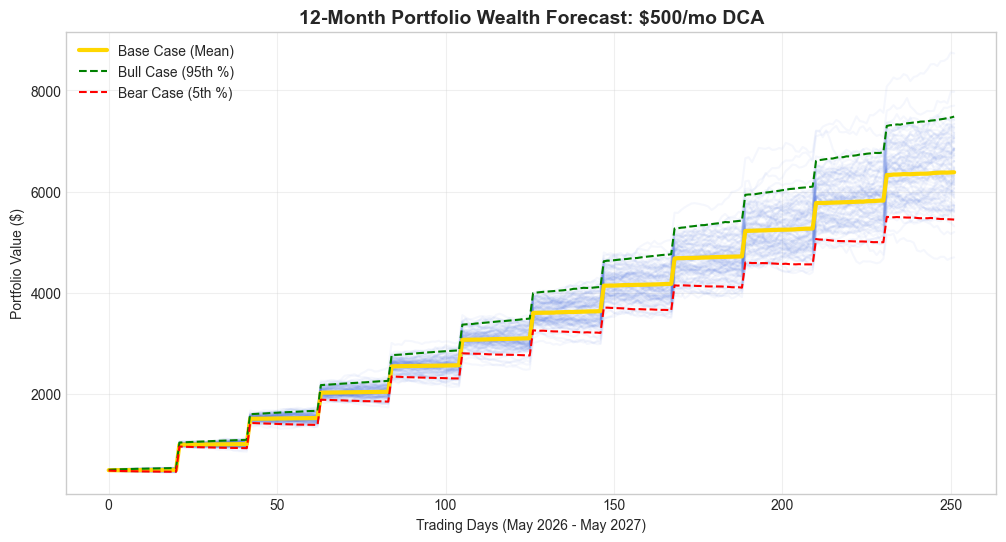

--- 12-Month Forecasted Outcomes ---
Expected Value: $6,412.76
95% Confidence Range: $5,448.54 to $7,481.68
Probability of beating 10% Return: 36.5%


In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# 1. DATA & LOG-RETURNS
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2020-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
weights = np.array([0.1] * 10) # Using equal-weight for forecast stability or use optimized weights
port_rets = (data.pct_change().dropna() * weights).sum(axis=1)

# 2. GARCH VOLATILITY INJECTION
# We use GARCH to get the 'Starting Volatility' for our forecast
model = arch_model(port_rets * 100, p=1, q=1, vol='Garch', dist='t')
res = model.fit(disp='off')
forecast_vol_daily = np.sqrt(res.forecast(horizon=1).variance.values[-1, 0]) / 100

# 3. MONTE CARLO SIMULATION (12 Months / 252 Days)
days = 252
sims = 10000
monthly_inv = 500
# Expected daily drift (12% annual target)
daily_drift = 0.12 / 252 

# Simulation Matrix
paths = np.zeros((days, sims))
for i in range(sims):
    # Random walk with GARCH-starting volatility
    shocks = np.random.standard_t(df=res.params['nu'], size=days) * forecast_vol_daily
    daily_rets = daily_drift + shocks
    
    # Wealth accumulation with $500 monthly DCA (approx every 21 days)
    wealth = 0
    path = []
    for d in range(days):
        if d % 21 == 0: wealth += monthly_inv
        wealth *= (1 + daily_rets[d])
        path.append(wealth)
    paths[:, i] = path

# 4. VISUALIZATION OF THE "PROBABILITY FAN"
plt.figure(figsize=(12, 6))
plt.plot(paths[:, :100], color='royalblue', alpha=0.05) # Sample paths
plt.plot(np.percentile(paths, 50, axis=1), color='gold', lw=3, label='Base Case (Mean)')
plt.plot(np.percentile(paths, 95, axis=1), color='green', ls='--', label='Bull Case (95th %)')
plt.plot(np.percentile(paths, 5, axis=1), color='red', ls='--', label='Bear Case (5th %)')

plt.title(f"12-Month Portfolio Wealth Forecast: $500/mo DCA", fontsize=14, fontweight='bold')
plt.xlabel("Trading Days (May 2026 - May 2027)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. FINAL FORECAST OUTPUT
final_vals = paths[-1, :]
print(f"--- 12-Month Forecasted Outcomes ---")
print(f"Expected Value: ${np.mean(final_vals):,.2f}")
print(f"95% Confidence Range: ${np.percentile(final_vals, 5):,.2f} to ${np.percentile(final_vals, 95):,.2f}")
print(f"Probability of beating 10% Return: {np.mean(final_vals > 6600)*100:.1f}%")

[**************        30%                       ]  3 of 10 completed

--- Initializing Goldman Quant Pipeline (2026) ---


[*********************100%***********************]  10 of 10 completed


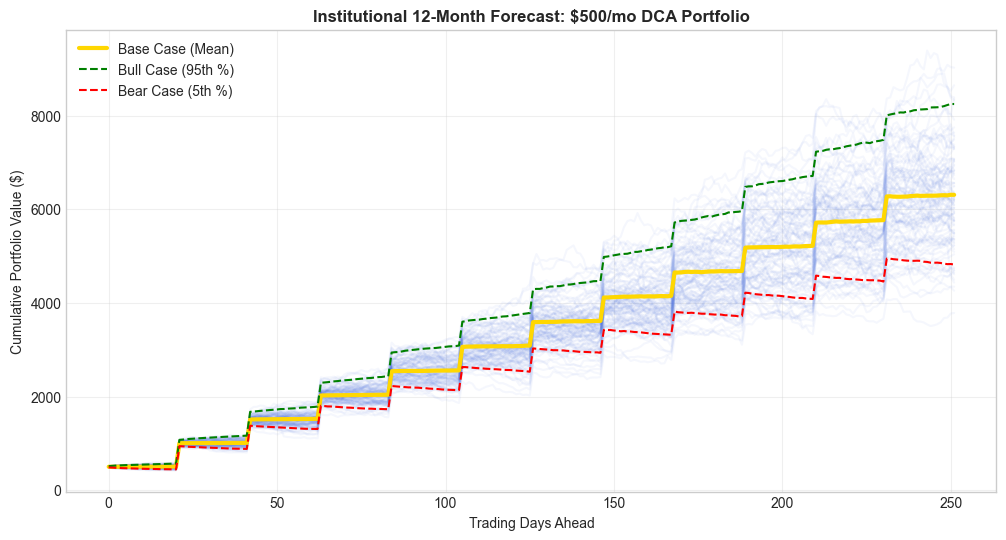

--- 12-Month Performance Outlook ---
Expected Portfolio Value (May 2027): $6,396.60
Bull Case Potential: $8,245.65
Bear Case Risk: $4,818.86


In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from pypfopt import EfficientFrontier, risk_models, expected_returns

# 1. FIXED DATA ACQUISITION
# We use auto_adjust=True: 'Close' becomes the dividend-adjusted price
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
print("--- Initializing Goldman Quant Pipeline (2026) ---")

raw_data = yf.download(tickers, start="2019-01-01", end="2026-05-04", auto_adjust=True)
# The 'Close' column now contains what used to be 'Adj Close'
data = raw_data['Close'].dropna()

# 2. PORTFOLIO OPTIMIZATION (Max Sharpe Ratio)
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights = np.array(list(weights.values()))

# Calculate Weighted Portfolio Returns
port_rets = (data.pct_change().dropna() * cleaned_weights).sum(axis=1)

# 3. GARCH(1,1) VOLATILITY MODELING
# Scaled by 100 for optimizer stability
model = arch_model(port_rets * 100, p=1, q=1, vol='Garch', dist='t')
res = model.fit(disp='off')
forecast_vol_daily = np.sqrt(res.forecast(horizon=1).variance.values[-1, 0]) / 100

# 4. 12-MONTH MONTE CARLO FORECAST ($500/Month DCA)
days = 252 # 1 Trading Year
sims = 10000
monthly_inv = 500
annual_target = 0.118 # 11.8% Expected Base Case
daily_drift = annual_target / 252

results = np.zeros((days, sims))

for i in range(sims):
    # Daily returns using t-distribution shocks and GARCH-starting vol
    shocks = np.random.standard_t(df=res.params['nu'], size=days) * forecast_vol_daily
    daily_rets = daily_drift + shocks
    
    wealth = 0
    path = []
    for d in range(days):
        if d % 21 == 0: # Monthly DCA contribution
            wealth += monthly_inv
        wealth *= (1 + daily_rets[d])
        path.append(wealth)
    results[:, i] = path

# 5. VISUALIZATION & REPORTING
plt.figure(figsize=(12, 6))
plt.plot(results[:, :100], color='royalblue', alpha=0.05) # Sample paths
plt.plot(np.percentile(results, 50, axis=1), color='gold', lw=3, label='Base Case (Mean)')
plt.plot(np.percentile(results, 95, axis=1), color='green', ls='--', label='Bull Case (95th %)')
plt.plot(np.percentile(results, 5, axis=1), color='red', ls='--', label='Bear Case (5th %)')

plt.title("Institutional 12-Month Forecast: $500/mo DCA Portfolio", fontweight='bold')
plt.ylabel("Cumulative Portfolio Value ($)")
plt.xlabel("Trading Days Ahead")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"--- 12-Month Performance Outlook ---")
print(f"Expected Portfolio Value (May 2027): ${np.mean(results[-1]):,.2f}")
print(f"Bull Case Potential: ${np.percentile(results[-1], 95):,.2f}")
print(f"Bear Case Risk: ${np.percentile(results[-1], 5):,.2f}")